In [85]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def offset_and_concat_by_file(dfs):
    adjusted = []
    running_max = 0
    for i, d in enumerate(dfs):
        d = d.copy()
        d["timestamp"] = d["timestamp"] + running_max
        adjusted.append(d)
        # set offset for next day/file
        running_max = d["timestamp"].max()
    return pd.concat(adjusted, ignore_index=True)


In [86]:
day_m2 = pd.read_csv('./data/ROUND_1/prices_round_1_day_-2.csv', sep=';')
day_m1 = pd.read_csv('./data/ROUND_1/prices_round_1_day_-1.csv', sep=';')
day_0 = pd.read_csv('./data/ROUND_1/prices_round_1_day_0.csv', sep=';')

df = offset_and_concat_by_file([day_m2, day_m1, day_0])

df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0


In [87]:
p1 = df[df["product"] == "INTARIAN_PEPPER_ROOT"]
p2 = df[df["product"] == "ASH_COATED_OSMIUM"]

p1.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0
7,-2,300,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,10006.0,10.0,10008.0,21.0,NaN,NaN,10006.0,0.0
9,-2,400,INTARIAN_PEPPER_ROOT,9992.0,20.0,NaN,NaN,NaN,NaN,10006.0,12.0,10008.0,20.0,NaN,NaN,9999.0,0.0


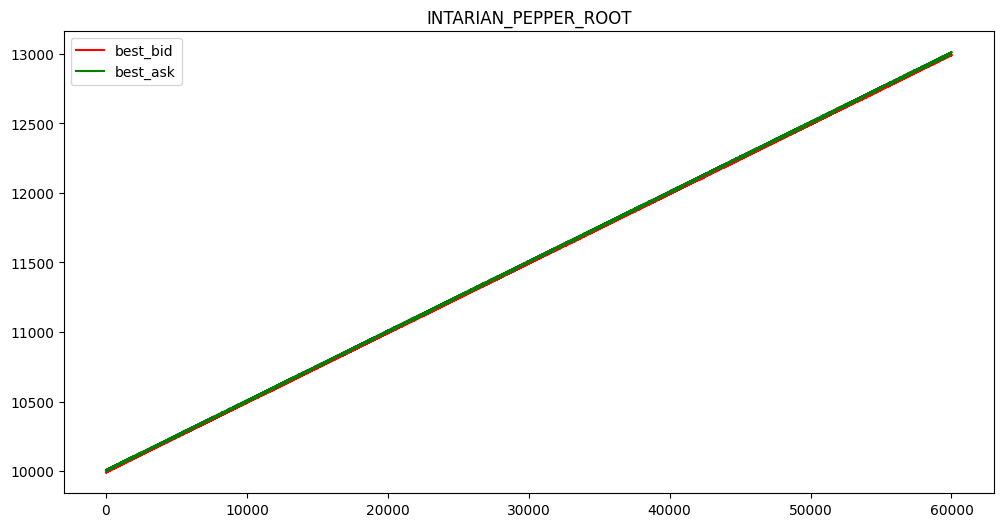

In [88]:
fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(p1["mid_price"], label="midprice")

timestamps = np.linspace(0, 60000, 100)
ax.plot(p1["bid_price_1"], color="red", label="best_bid")
ax.plot(p1["ask_price_1"], color="green", label="best_ask")
# ax.plot(timestamps, 10000+timestamps*1e-2*5)
plt.legend()
plt.title("INTARIAN_PEPPER_ROOT")
plt.show()





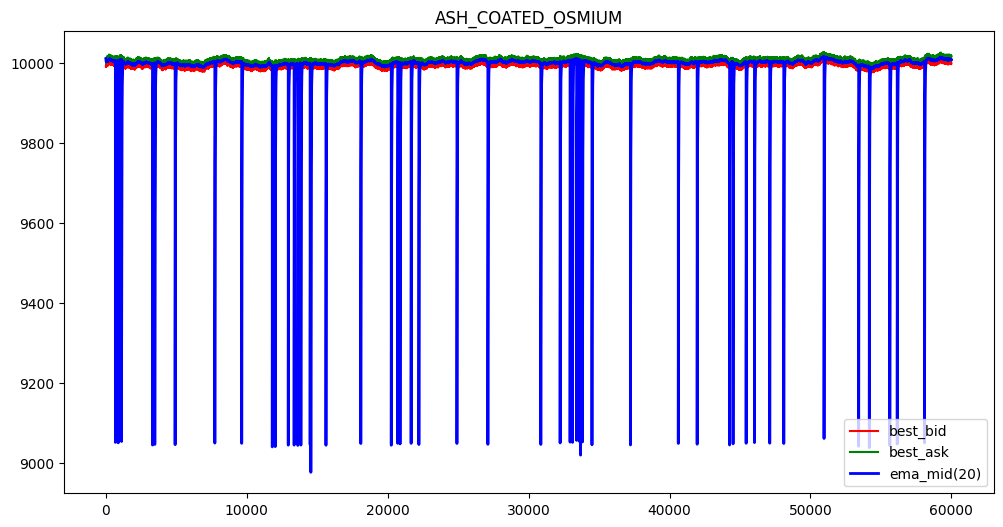

In [96]:
fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(p1["mid_price"], label="midprice")
ax.plot(p2["bid_price_1"], color="red", label="best_bid")
ax.plot(p2["ask_price_1"], color="green", label="best_ask")

mid_price = (p2["bid_price_1"] + p2["ask_price_1"]) / 2
ema_span = 20
ema_mid_price = mid_price.ewm(span=ema_span, adjust=False).mean()
ax.plot(ema_mid_price, color="blue", linewidth=2, label=f"ema_mid({ema_span})")

plt.legend()
plt.title("ASH_COATED_OSMIUM")
plt.show()



In [90]:
day_m2_trades = pd.read_csv('./data/ROUND_1/trades_round_1_day_-2.csv', sep=';')
day_m1_trades = pd.read_csv('./data/ROUND_1/trades_round_1_day_-1.csv', sep=';')
day_0_trades = pd.read_csv('./data/ROUND_1/trades_round_1_day_0.csv', sep=';')
df_trades = offset_and_concat_by_file([day_m2_trades, day_m1_trades, day_0_trades])


In [91]:
df_trades.head(n=10)

,timestamp,buyer,seller,symbol,currency,price,quantity
0,700,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9990.0,6
1,900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9998.0,2
2,1000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,9995.0,7
3,2500,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10011.0,8
4,4000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10007.0,7
5,6100,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10013.0,8
6,10500,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10013.0,5
7,12600,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10018.0,3
8,12900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10001.0,9
9,13800,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10017.0,3


In [92]:
p1_trades = df_trades[df_trades["symbol"] == "INTARIAN_PEPPER_ROOT"]
p2_trades = df_trades[df_trades["symbol"] == "ASH_COATED_OSMIUM"]



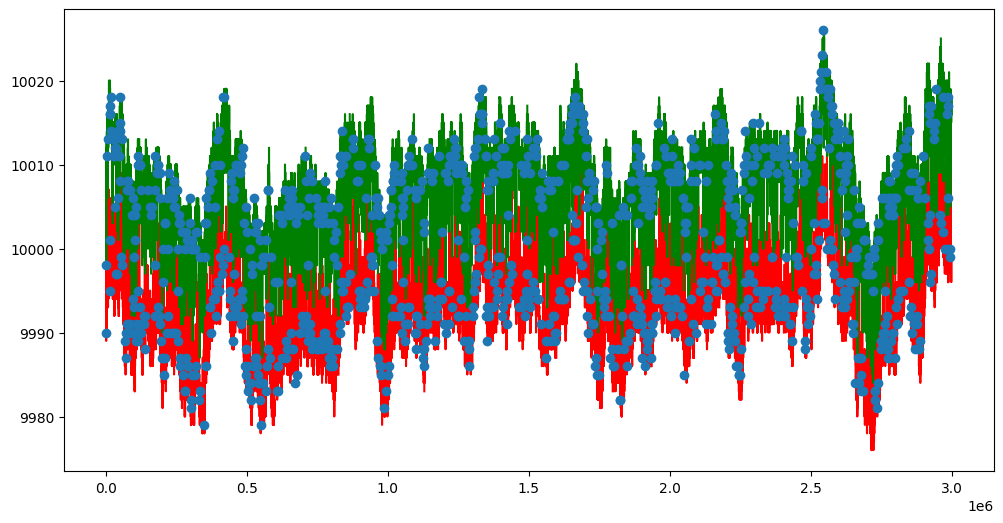

In [93]:
fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(tomatoes["timestamp"], tomatoes["mid_price"])
ax.plot(p2["timestamp"], p2["bid_price_1"], color="red")
ax.plot(p2["timestamp"], p2["ask_price_1"], color="green")
ax.plot(p2_trades["timestamp"], p2_trades["price"], 'o')
plt.show()


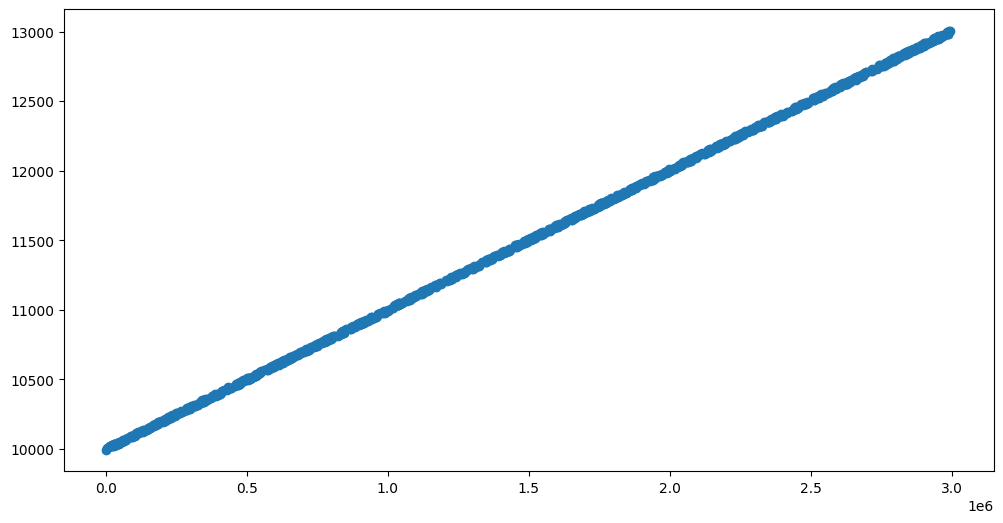

In [95]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(p1["timestamp"], p1["bid_price_1"], color="red")
ax.plot(p1["timestamp"], p1["ask_price_1"], color="green")
ax.plot(p1_trades["timestamp"], p1_trades["price"], 'o')
plt.show()

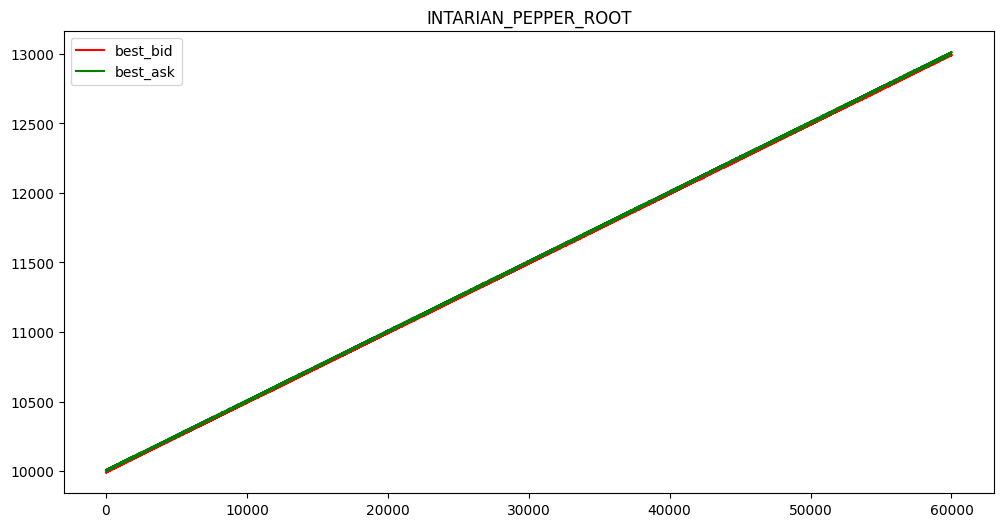

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(p1["mid_price"], label="midprice")

timestamps = np.linspace(0, 60000, 100)
ax.plot(p1["bid_price_1"], color="red", label="best_bid")
ax.plot(p1["ask_price_1"], color="green", label="best_ask")
# ax.plot(timestamps, 10000+timestamps*1e-2*5)
plt.legend()
plt.title("INTARIAN_PEPPER_ROOT")
plt.show()

In [ ]:
import json

with open('./89328/89328.json', 'r') as f:
    d = json.load(f)

print(d['activitiesLog'])

FileNotFoundError: [Errno 2] No such file or directory: './89328/89328.json'

In [ ]:
from io import StringIO

df3 = pd.read_csv(StringIO(d['activitiesLog']), sep=';')

In [ ]:
df3.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,6,4998,19,NaN,NaN,5013,6,5014,19,NaN,NaN,5006.0,0.0
1,-1,0,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,13,9990,30,NaN,NaN,10008,13,10010,30,NaN,NaN,10000.0,0.0
3,-1,100,TOMATOES,5000,5,4998,23,NaN,NaN,5013,5,5014,23,NaN,NaN,5006.5,0.0
4,-1,200,EMERALDS,9992,13,9990,21,NaN,NaN,10008,13,10010,21,NaN,NaN,10000.0,0.0


In [ ]:
tomatoes_log = df3[df3["product"] == "TOMATOES"]

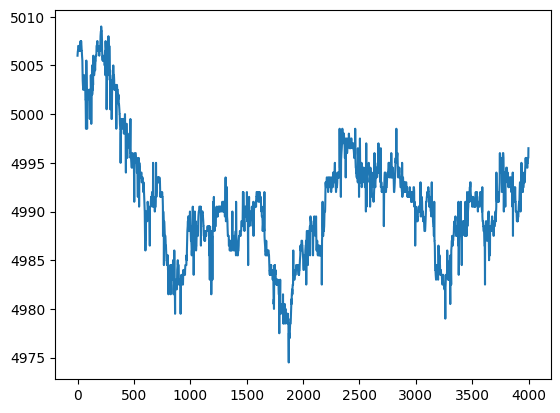

In [ ]:
plt.plot(tomatoes_log["mid_price"])

In [ ]:
import json
import pandas as pd
import io

# 1. Load the actual file as JSON
with open("data/logs/91389/91389.log", 'r') as f:
    json_data = json.load(f)

# 2. Extract the specific log string
raw_log_string = json_data['activitiesLog']

# 3. Convert that string into a DataFrame
df = pd.read_csv(io.StringIO(raw_log_string), sep=';')

df.head()
# df4 = pd.read_csv("data/logs/91389/91389.log", sep=";", engine='python')

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,6,4998,19,NaN,NaN,5013,6,5014,19,NaN,NaN,5006.0,0.0
1,-1,0,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,13,9990,30,NaN,NaN,10008,13,10010,30,NaN,NaN,10000.0,0.0
3,-1,100,TOMATOES,5000,5,4998,23,NaN,NaN,5013,5,5014,23,NaN,NaN,5006.5,0.0
4,-1,200,EMERALDS,9992,13,9990,21,NaN,NaN,10008,13,10010,21,NaN,NaN,10000.0,0.0
